In [ ]:
import sys

import seaborn as sns, sys
print(sys.executable)
print(sns.__version__, sys.executable)
import matplotlib.pyplot as plt
import pandas as pd

##FB7035
my_palette = sns.color_palette(['#FCB209', '#FF7F50', '#FB751C','#bb4449','#700E18'])
blue_palette = sns.color_palette(["#b9d6f2ff", "#0353a4ff", "#006daaff", "#003559ff", "#061a40ff"])
cvd_safe_palette = ["#F4C430", "#F08A4B", "#E77E4D", "#C85A63", "#8E2C3C"]

from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path().resolve()


/Library/Developer/CommandLineTools/usr/bin/python3
0.13.2 /Library/Developer/CommandLineTools/usr/bin/python3


In [2]:



def process(filepath):
    df = pd.read_excel(filepath, engine="xlrd")
    tmp = df.copy()
    tmp["Depth"] = tmp["Depth"].str.strip()
    tmp = tmp[tmp["Depth"].isin(["> > >","> > > >"])]
    return tmp
    
d3 = process(PROJECT_ROOT/"20251115_DASIT_MBESv2_D3.xls")
d5 = process(PROJECT_ROOT/"20251117_DASIT_MBESv2_D5.xls")
d7 = process(PROJECT_ROOT/"20251119_DASIT_MBESv2_D7.xls")
d13 = process(PROJECT_ROOT/"20251125_DASIT_MBESv2_D13.xls")
print(d5)

# do some processing and remove neg control rows
def remove_controls(df):
    df = df[~df['Name'].str.contains('control', na=False)]
    return df

def extract_base_name(df):
    df["base_name"] = (
        df["Name"].str.split(".").str[0].str.split("_").str[1:3].str.join("_")
    )
    return df

def add_gate_column(df):
    df["gate"] = df["Depth"].apply(lambda x: "live" if x == "> > >" else ("GFP+" if x == "> > > >" else "unknown"))
    return df

def add_screenDay(df, day):
    df["screenDay"] = day
    return df

def clean_data(df, day):
    df = remove_controls(df)
    df = extract_base_name(df)
    df = add_gate_column(df)
    df = add_screenDay(df, day)
    return df.sort_values(by=["gate", "base_name"])


      Depth                                               Name  Statistic  \
3     > > >  111725_control_noZombie.fcs/singlets1/singlets...      59.40   
4   > > > >  111725_control_noZombie.fcs/singlets1/singlets...       1.71   
8     > > >    111725_nopuro_rep1.fcs/singlets1/singlets2/live      92.80   
9   > > > >  111725_nopuro_rep1.fcs/singlets1/singlets2/liv...      56.90   
13    > > >    111725_nopuro_rep2.fcs/singlets1/singlets2/live      91.00   
14  > > > >  111725_nopuro_rep2.fcs/singlets1/singlets2/liv...      51.80   
18    > > >    111725_nopuro_rep3.fcs/singlets1/singlets2/live      90.90   
19  > > > >  111725_nopuro_rep3.fcs/singlets1/singlets2/liv...      52.50   
23    > > >      111725_puro_rep1.fcs/singlets1/singlets2/live      84.00   
24  > > > >  111725_puro_rep1.fcs/singlets1/singlets2/live/...      98.50   
28    > > >      111725_puro_rep2.fcs/singlets1/singlets2/live      85.70   
29  > > > >  111725_puro_rep2.fcs/singlets1/singlets2/live/...      98.30   

In [3]:
d3_clean = clean_data(d3, 3)
d5_clean = clean_data(d5, 5)
d7_clean = clean_data(d7, 7)
d13_clean = clean_data(d13, 13)

for df in [d3_clean, d5_clean, d7_clean, d13_clean]:
    df["condition"] = df["base_name"].str.extract(r'^(nopuro|puro)')

# Combine all into one dataframe
all_df = pd.concat([d3_clean, d5_clean, d7_clean, d13_clean], ignore_index=True)

df_GFP = all_df[all_df['gate'] == 'GFP+']

/var/folders/gc/rb87b42j4jx3nbj4c8r287cw0000gn/T/ipykernel_95630/2160508283.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["base_name"] = (
/var/folders/gc/rb87b42j4jx3nbj4c8r287cw0000gn/T/ipykernel_95630/2160508283.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["gate"] = df["Depth"].apply(lambda x: "live" if x == "> > >" else ("GFP+" if x == "> > > >" else "unknown"))
/var/folders/gc/rb87b42j4jx3nbj4c8r287cw0000gn/T/ipykernel_95630/2160508283.py:30: SettingWithCopyWarning: 
A value is try

/var/folders/gc/rb87b42j4jx3nbj4c8r287cw0000gn/T/ipykernel_95630/3975942288.py:11: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
/var/folders/gc/rb87b42j4jx3nbj4c8r287cw0000gn/T/ipykernel_95630/3975942288.py:11: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.5}` instead.

  sns.barplot(


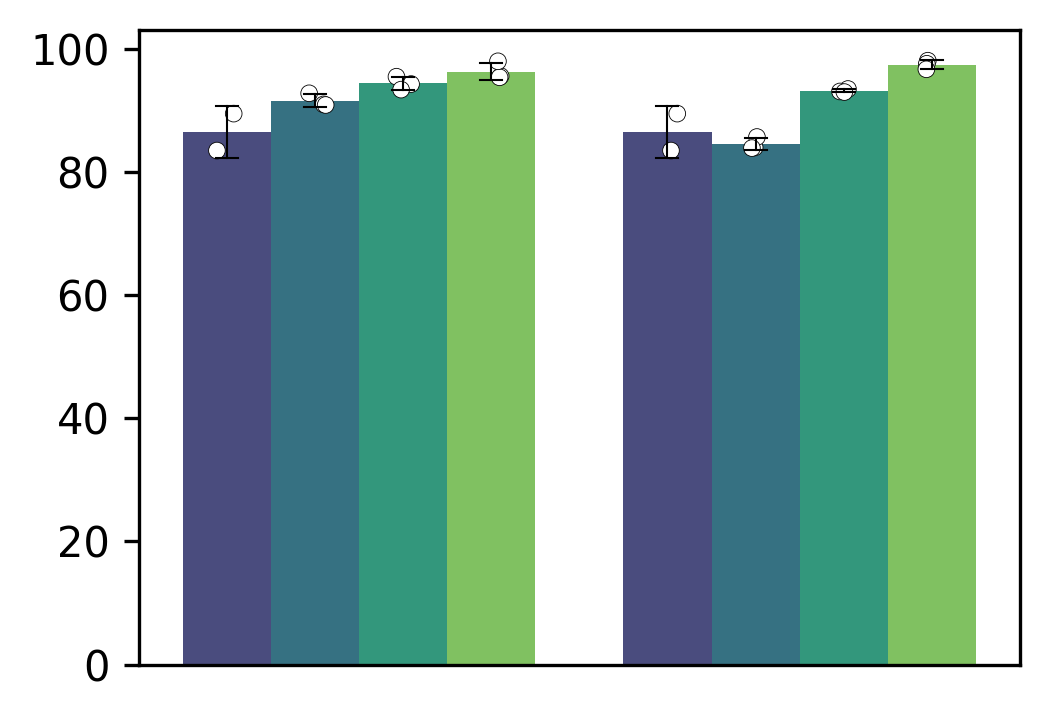

In [4]:
import matplotlib.pyplot as plt
plt.style.use("default")
df_live = all_df[all_df['gate'] == 'live']

plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots(figsize=(4,2.5))

hue_levels = df_live["screenDay"].unique()
palette = {h: "white" for h in hue_levels}

sns.barplot(
    data=df_live,
    x="condition",
    y="Statistic",
    hue="screenDay",
    palette = sns.color_palette("viridis", n_colors=4)[0:],
    errorbar="sd",
    errcolor="black",
    errwidth=0.5,
    capsize=0.2,
    #edgecolor="black",
    alpha = 1,
    zorder = 1,
    err_kws={"zorder": 3},
    ax=ax,
)

# Replicate dots
sns.stripplot(
    data=df_live,
    x="condition",
    y="Statistic",
    hue="screenDay",
    palette = palette,
    dodge=True,
    jitter=0.1,
    size=4,
    alpha=1,
    linewidth=0.2,
    edgecolor="black",
    ax=ax,
    zorder = 2,
    legend=False    
)



# reuse the Matplotlib styling from the other plot


ax.set_ylabel("") # or %Viability
ax.set_yticks([0, 20, 40, 60, 80, 100])
#ax.set_xticklabels(["No puro", "5 µg/mL puro"], fontsize=8)
#ax.tick_params(axis='x', pad=15)
#ax.tick_params(axis='x', which='both', bottom=False, top=False)

#highlight = {"boxstyle": "round,pad=0.1", "facecolor":"lightgray", "edgecolor": "none"}
#for lbl in ax.get_xticklabels():
#    lbl.set_bbox(highlight)
#ax.set_xlabel("Selection condition")
ax.set_xticks([])
ax.set_xlabel("")
ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
#ax.set_box_aspect(1)

""" ax.annotate(
    "",
    xy=(0.8, 0), xycoords=("data", "axes fraction"),
    xytext=(0, -8.2), textcoords="offset points",
    arrowprops=dict(arrowstyle="-|>", lw=0.5, mutation_scale=9, color="black"),
)

# text placed independently
ax.text(
    .6, -0.052, "+ puro",  # pick coords you want
    transform=ax.transAxes, ha="center", va="top", fontsize=5
)

ax.annotate(
    "- puro",
    xy=(1, 0),                # arrow tip at x-axis
    xycoords=('data', 'axes fraction'),
    xytext=(0, -8.2),                    # move text downward
    textcoords='offset points',
    arrowprops=dict(arrowstyle='-|>', lw=.5, mutation_scale=9, color='black'),
    ha='center', va='top',
    fontsize=5
) """

#ax.set_title("Triplicate screen Viability")
#ax.legend(title = "Screen Day", frameon=False,loc="center left", bbox_to_anchor=(1.02, 0.5))
#sns.move_legend(ax, labels=l[-len(hue_order):], loc='upper left', bbox_to_anchor=(1,1), frameon=False)
ax.legend_.remove()

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()


/var/folders/gc/rb87b42j4jx3nbj4c8r287cw0000gn/T/ipykernel_95630/2470973416.py:9: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
/var/folders/gc/rb87b42j4jx3nbj4c8r287cw0000gn/T/ipykernel_95630/2470973416.py:9: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.5}` instead.

  sns.barplot(


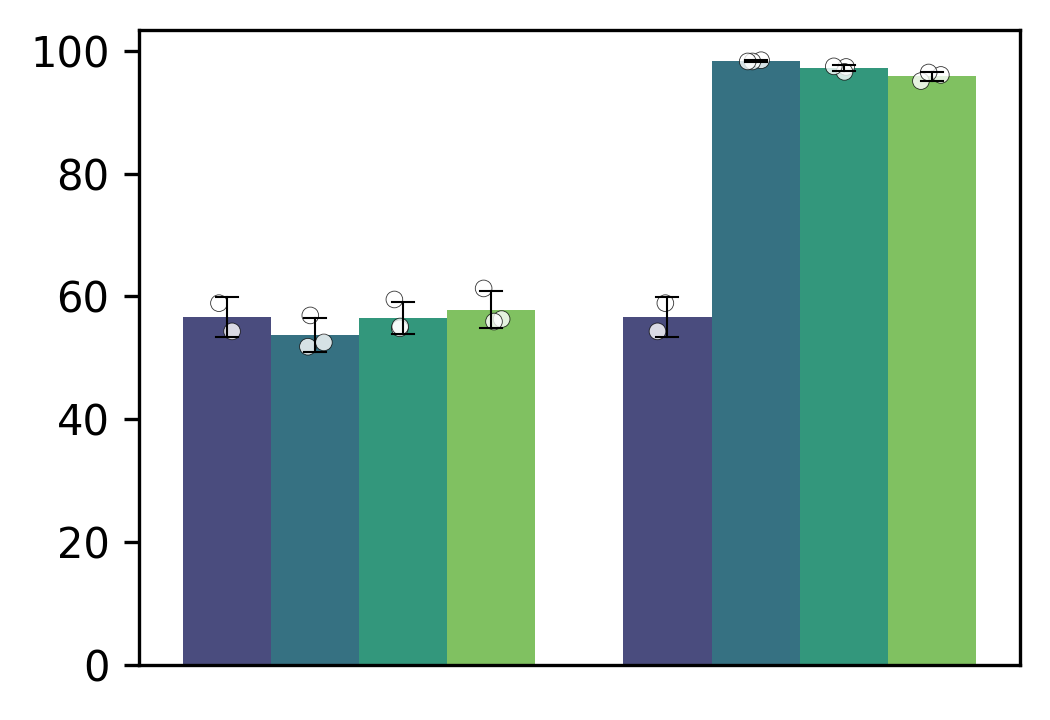

In [5]:

import matplotlib.pyplot as plt
plt.style.use("default")
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots(figsize=(4, 2.5))

hue_levels = df_live["screenDay"].unique()
palette = {h: "white" for h in hue_levels}

sns.barplot(
    data=df_GFP,
    x="condition",
    y="Statistic",
    hue="screenDay",
    palette = sns.color_palette("viridis", n_colors=4)[0:],
    errorbar="sd",
    errcolor="black",
    errwidth=0.5,
    capsize=0.2,
    alpha = 1,
    zorder = 1,
    err_kws={"zorder": 3},
    ax=ax,
)
# Replicate dots
sns.stripplot(
    data=df_GFP,
    x="condition",
    y="Statistic",
    hue="screenDay",
    palette = palette,
    dodge=True,
    size=4,
    alpha=0.8,
    linewidth=0.2,
    jitter=0.1,
    edgecolor="black",
    ax=ax,
    zorder = 2,
    legend=False    
)



# reuse the Matplotlib styling from the other plot
#ax.set_title("Triplicate screen GFP+ selection")
#ax.set_xlabel("Condition")
ax.set_ylabel("") # or % GFP+ cells

ax.set_yticks([0, 20, 40, 60, 80, 100])
#ax.set_xticklabels(["No puro", "5 µg/mL puro"], fontsize=8)
#ax.tick_params(axis='x', which='both', bottom=False, top=False)
#ax.tick_params(axis='x', pad=15)
#highlight = {"boxstyle": "round,pad=0.1", "facecolor":"lightgray", "edgecolor": "none"}
#for lbl in ax.get_xticklabels():
#    lbl.set_bbox(highlight)
#ax.set_xlabel("Selection condition")


# x-locations for categories

# Add arrows under the x-axis
""" ax.annotate(
    "",
    xy=(0.8, 0), xycoords=("data", "axes fraction"),
    xytext=(0, -8.2), textcoords="offset points",
    arrowprops=dict(arrowstyle="-|>", lw=0.5, mutation_scale=9, color="black"),
)

# text placed independently
ax.text(
    .6, -0.052, "+ puro",  # pick coords you want
    transform=ax.transAxes, ha="center", va="top", fontsize=5
)

ax.annotate(
    "- puro",
    xy=(1, 0),                # arrow tip at x-axis
    xycoords=('data', 'axes fraction'),
    xytext=(0, -8.2),                    # move text downward
    textcoords='offset points',
    arrowprops=dict(arrowstyle='-|>', lw=.5, mutation_scale=9, color='black'),
    ha='center', va='top',
    fontsize=5
)
 """

#ax.legend(title = "Screen Day", frameon=False,loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.legend_.remove()
ax.set_xticks([])
ax.set_xlabel("")
ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

#ax.set_box_aspect(1)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()